# **Generative Text Modelling: A Comparative Analysis of Architecture and Tokenisation**

**Author: Levy Thiga Kariuki G20893080**

## Overview
This notebook presents a structured investigation into generative text modelling using deep learning techniques. The project explores the effectiveness of different architectures and data representations in generating evaluative text.

The study is divided into two phases:
1. **Pilot Experiment (WikiText-2)** – to validate the modelling pipeline
2. **Main Experiment (IMDb Reviews)** – to generate feedback-style text and evaluate performance

Key components include:
- Baseline vs advanced model comparison (**LSTM vs Transformer**)
- Tokenisation strategies (word-level vs BPE)
- Controlled generation experiments
- Sustainability-aware training constraints

## Table of Contents

1. Environment Setup & Shared Utilities  

2. Pilot Study: WikiText-2  
   2.1 Dataset Loading  
   2.2 Dataset Exploration (EDA)  
   2.3 Tokenisation Strategy (Transparent + Sustainability-Aware)  
   2.4 LSTM Model  
   2.5 Transformer Model  
   2.6 Generation + Results  
   2.7 Key Observations  

3. Main Experiment: IMDb Reviews  
   3.1 Dataset Loading  
   3.2 Dataset Exploration (EDA)  
   3.3 Tokenisation (Word-Level)  
   3.4 LSTM Model  
   3.5 Transformer Model  
   3.6 Initial Observations  

4. Sampling Strategy Improvements  

5. Ablation Study: Tuned Transformer  

6. Tokenisation Upgrade: BPE  

7. Controlled Generation Experiment

8. Final Summary

##Pipeline Diagram:

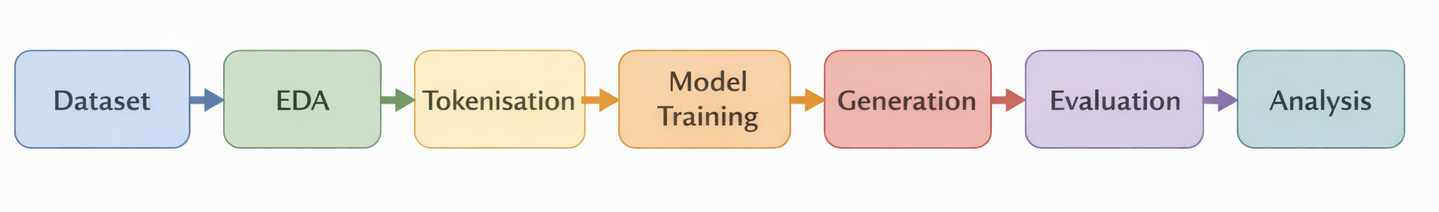

## 1. Environment Setup & Shared Utilities


In [ ]:
# ---------------------------------------------------
# Install + Imports (Colab)
# ---------------------------------------------------
!pip -q install datasets

import os, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from collections import Counter
from torch.utils.data import Dataset, DataLoader

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# 2. Pilot Study: **WikiText-2**

This section evaluates generative modelling on a general-purpose dataset to establish a baseline pipeline before moving to a more task-aligned dataset.

link to dataset: https://huggingface.co/datasets/Salesforce/wikitext

### 2.1 Dataset Loading

In [ ]:
# ---------------------------------------------------
# Load Dataset (auto-downloads)
# ---------------------------------------------------
# Link: https://huggingface.co/datasets/Salesforce/wikitext
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")
print(dataset)

train_lines = len(dataset["train"])
val_lines = len(dataset["validation"])
test_lines = len(dataset["test"])
print("Lines (train/val/test):", train_lines, val_lines, test_lines)

# Peek
print("\nSample line:")
print(dataset["train"]["text"][10][:400])


### 2.2 Dataset Exploration (EDA)

This analysis provides insight into dataset structure, informing decisions on sequence length, vocabulary size, and modelling strategy.

In [ ]:
# ---------------------------------------------------
# WikiText EDA: Dataset Exploration
# ---------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Define tokenizer
def basic_tokenize(text: str):
    return text.lower().split()

# Extract non-empty lines
wikitext_train_texts = [t for t in dataset["train"]["text"] if t and t.strip()]
wikitext_val_texts = [t for t in dataset["validation"]["text"] if t and t.strip()]
wikitext_test_texts = [t for t in dataset["test"]["text"] if t and t.strip()]

print("=== WIKITEXT DATASET SUMMARY ===")
print("Non-empty train lines:", len(wikitext_train_texts))
print("Non-empty validation lines:", len(wikitext_val_texts))
print("Non-empty test lines:", len(wikitext_test_texts))

# Token lengths
wikitext_lengths = [len(basic_tokenize(t)) for t in wikitext_train_texts]

print("\n=== WIKITEXT TOKEN LENGTH STATS ===")
print("Average length:", np.mean(wikitext_lengths))
print("Median length:", np.median(wikitext_lengths))
print("Min length:", np.min(wikitext_lengths))
print("Max length:", np.max(wikitext_lengths))

# Vocabulary statistics
all_wikitext_tokens = []
for t in wikitext_train_texts:
    all_wikitext_tokens.extend(basic_tokenize(t))

unique_tokens = len(set(all_wikitext_tokens))
print("\n=== WIKITEXT VOCABULARY STATS ===")
print("Total tokens:", len(all_wikitext_tokens))
print("Unique tokens:", unique_tokens)

# Examples
print("\n=== SAMPLE WIKITEXT LINES ===")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(wikitext_train_texts[i][:500])

# Plot
plt.figure(figsize=(8, 5))
plt.hist(wikitext_lengths, bins=50)
plt.title("WikiText-2 Length Distribution")
plt.xlabel("Tokens per line")
plt.ylabel("Frequency")
plt.show()

## 2.3 Tokenisation strategy (transparent + sustainability-aware)

To keep the pipeline explainable (and not “magic pretraining”), I use a **simple word-level tokenizer** with a **vocabulary cap** (default 20k). This also supports the sustainability by limiting model size.

In [ ]:
# ---------------------------------------------------
# Word-level Tokeniser + Vocab
# ---------------------------------------------------
def basic_tokenize(text: str):
    return text.lower().split()

# Build vocab from train split
tokens = []
for t in dataset["train"]["text"]:
    if t and t.strip():
        tokens.extend(basic_tokenize(t))

VOCAB_SIZE = 20000  # sustainability cap (adjust if needed)
counter = Counter(tokens)
most_common = counter.most_common(VOCAB_SIZE - 2)

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

def encode(text: str, max_len=256):
    ids = [stoi.get(w, UNK_IDX) for w in basic_tokenize(text)]
    return ids[:max_len]

def decode(ids):
    return " ".join(itos[i] for i in ids if i != PAD_IDX)

print("Vocab size:", len(itos))
print("Example tokens:", tokens[:20])


## Build fixed-length sequences for language modelling

Training with **next-token prediction**. Each sequence `x` predicts the shifted sequence `y`.
- `SEQ_LEN` is capped to control compute and enable fair comparisons.

In [ ]:
# ---------------------------------------------------
# Build LM Sequences + DataLoaders
# ---------------------------------------------------
SEQ_LEN = 64  # 128 can improve quality but costs more compute

def build_sequences(split_texts):
    all_ids = []
    for t in split_texts:
        if t and t.strip():
            all_ids.extend(encode(t))
    seqs = []
    for i in range(0, len(all_ids) - SEQ_LEN - 1, SEQ_LEN):
        x = all_ids[i:i+SEQ_LEN]
        y = all_ids[i+1:i+SEQ_LEN+1]
        seqs.append((x, y))
    return seqs

train_seqs = build_sequences(dataset["train"]["text"])
val_seqs   = build_sequences(dataset["validation"]["text"])
test_seqs  = build_sequences(dataset["test"]["text"])

print("Sequences (train/val/test):", len(train_seqs), len(val_seqs), len(test_seqs))

class LMDataset(Dataset):
    def __init__(self, seqs): self.seqs = seqs
    def __len__(self): return len(self.seqs)
    def __getitem__(self, idx):
        x, y = self.seqs[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

BATCH_SIZE = 128
train_dl = DataLoader(LMDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_dl   = DataLoader(LMDataset(val_seqs), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_dl  = DataLoader(LMDataset(test_seqs), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print("Batch size:", BATCH_SIZE)


## Shared training + evaluation utilities

Includes:
- **Perplexity** (standard LM metric)
- **Gradient clipping**
- **Time budget** for sustainability
- Best-checkpoint saving (by validation loss)

In [ ]:
# ---------------------------------------------------
# Train/Eval Utilities
# ---------------------------------------------------
def evaluate(model, dl):
    # Switch model to evaluation mode (no dropout, no training updates)
    model.eval()
    total_loss, total_tokens = 0.0, 0

    # Disable gradient computation for efficiency
    with torch.no_grad():
        for x, y in dl:
            # Move batch to device (CPU/GPU)
            x, y = x.to(device), y.to(device)

            # Forward pass
            logits = model(x)

            # Compute cross-entropy loss (ignore padding tokens)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                ignore_index=PAD_IDX
            )

            # Accumulate total loss weighted by number of tokens
            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()

    # Average loss across all tokens
    avg_loss = total_loss / total_tokens

    # Convert loss to perplexity
    ppl = math.exp(avg_loss)

    return avg_loss, ppl

def train_model(model, train_dl, val_dl, epochs=10, lr=2e-3, max_minutes=25, clip=1.0, save_path="best.pt"):
    # Move model to correct device
    model.to(device)

    # Adam optimiser (works well for NLP tasks)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    best_val = float("inf")
    start = time.time()

    # Store training history for later analysis
    hist = {"train_loss": [], "val_loss": [], "val_ppl": [], "epoch_time_s": []}

    for ep in range(1, epochs+1):
        t0 = time.time()

        # Set model to training mode
        model.train()

        running, tokens = 0.0, 0

        for x, y in train_dl:
            # Move batch to device
            x, y = x.to(device), y.to(device)

            # Reset gradients
            opt.zero_grad()

            # Forward pass
            logits = model(x)

            # Compute loss (flattened for token-level prediction)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                ignore_index=PAD_IDX
            )

            # Backpropagation
            loss.backward()

            # Gradient clipping to stabilise training
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

            # Update model weights
            opt.step()

            # Track loss and token count
            running += loss.item() * y.numel()
            tokens += y.numel()

            # Stop early if time budget is exceeded (sustainability constraint)
            if (time.time() - start) > max_minutes * 60:
                break

        # Compute average training loss
        train_loss = running / tokens

        # Evaluate on validation set
        val_loss, val_ppl = evaluate(model, val_dl)

        epoch_time = time.time() - t0

        # Store metrics
        hist["train_loss"].append(train_loss)
        hist["val_loss"].append(val_loss)
        hist["val_ppl"].append(val_ppl)
        hist["epoch_time_s"].append(epoch_time)

        # Print progress
        print(f"Epoch {ep:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_ppl={val_ppl:.2f} | time={epoch_time:.1f}s")

        # Save best model based on validation loss
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)

        # Stop training if time limit reached
        if (time.time() - start) > max_minutes * 60:
            print("Stopped early due to time budget (sustainability constraint).")
            break

    return hist


## 2.4 LSTM Model
# Baseline Model: **LSTM Language Model**

In [ ]:
# ---------------------------------------------------
# Baseline: LSTM LM
# ---------------------------------------------------
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            emb_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        e = self.emb(x)
        out, _ = self.lstm(e)
        return self.fc(out)

lstm = LSTMLM(len(itos), emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2)
lstm_hist = train_model(lstm, train_dl, val_dl, epochs=8, lr=2e-3, max_minutes=25, save_path="best_lstm.pt")


##2.5 Transformer Model
# Main Model: **Small Transformer Decoder LM** (Causal)

This is a compact Transformer with:
- token + positional embeddings
- encoder blocks used with a **causal mask** (decoder-style autoregressive behaviour)
- constrained depth/width for sustainability and fairness of comparison

In [ ]:
# ---------------------------------------------------
# Main: Small Transformer Decoder LM
# ---------------------------------------------------
class TransformerLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, n_heads=4, n_layers=4, ff_dim=1024, dropout=0.1, max_len=SEQ_LEN):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_len, emb_dim)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        B, T = x.size()
        pos = torch.arange(0, T, device=x.device).unsqueeze(0).expand(B, T)
        h = self.tok_emb(x) + self.pos_emb(pos)

        # Causal mask: prevent attention to future tokens
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        h = self.encoder(h, mask=causal_mask)
        return self.fc(h)

tr = TransformerLM(len(itos), emb_dim=256, n_heads=4, n_layers=4, ff_dim=1024, dropout=0.1)
tr_hist = train_model(tr, train_dl, val_dl, epochs=12, lr=2e-4, max_minutes=30, save_path="best_transformer.pt")


## 2.6 Generation + Results
## Generation: compare samples (LSTM vs Transformer)

In [ ]:
# ---------------------------------------------------
# Text Generation
# ---------------------------------------------------
@torch.no_grad()
def generate(model, prompt_text, max_new_tokens=60, temperature=0.9):
    model.eval()
    ids = encode(prompt_text)
    if len(ids) == 0:
        ids = [UNK_IDX]
    ids = ids[:SEQ_LEN]
    x = torch.tensor(ids, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        inp = x[:, -SEQ_LEN:] if x.size(1) >= SEQ_LEN else x
        logits = model(inp)[:, -1, :] / max(temperature, 1e-6)
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)

    return decode(x.squeeze(0).tolist())

# Load best checkpoints
lstm_best = LSTMLM(len(itos), emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2).to(device)
lstm_best.load_state_dict(torch.load("best_lstm.pt", map_location=device))

tr_best = TransformerLM(len(itos), emb_dim=256, n_heads=4, n_layers=4, ff_dim=1024, dropout=0.1).to(device)
tr_best.load_state_dict(torch.load("best_transformer.pt", map_location=device))

prompts = [
    "the purpose of this",
    "in conclusion",
    "this article describes",
    "a key limitation is",
]

for p in prompts:
    print("\nPROMPT:", p)
    print("LSTM:", generate(lstm_best, p))
    print("TR  :", generate(tr_best, p))


### Final Evaluation + Reproducibility Log

In [ ]:
# ---------------------------------------------------
# Test Evaluation + Repro Log
# ---------------------------------------------------
lstm_test_loss, lstm_test_ppl = evaluate(lstm_best, test_dl)
tr_test_loss, tr_test_ppl = evaluate(tr_best, test_dl)

print("\n=== TEST RESULTS ===")
print(f"LSTM: loss={lstm_test_loss:.4f}, ppl={lstm_test_ppl:.2f}")
print(f"TR  : loss={tr_test_loss:.4f}, ppl={tr_test_ppl:.2f}")

repro = f"""Run date: {time.strftime('%Y-%m-%d %H:%M:%S')}
Device: {device}
Dataset: Salesforce/wikitext (config=wikitext-2-raw-v1)
Vocab cap: {VOCAB_SIZE}
SEQ_LEN: {SEQ_LEN}
Batch size: {BATCH_SIZE}

Baseline (LSTM):
- emb=256 hidden=512 layers=2 dropout=0.2 lr=2e-3
- epochs={len(lstm_hist['train_loss'])}
- test_ppl={lstm_test_ppl:.2f}

Main (Transformer):
- emb=256 heads=4 layers=4 ff=1024 dropout=0.1 lr=2e-4
- epochs={len(tr_hist['train_loss'])}
- test_ppl={tr_test_ppl:.2f}

Sustainability notes:
- Model sizes constrained (vocab cap, seq length, depth/width)
- Time budgets enforced in training loops (early stopping if exceeded)
"""

with open("reproducibility_log.md", "w") as f:
    f.write(repro)

print("\nSaved reproducibility_log.md")
print(repro)


# 2.7 Key Observations

- Transformer slightly outperformed LSTM in perplexity
- Outputs were structurally coherent but lacked evaluative alignment
- Dataset characteristics limited suitability for feedback-style generation

# 3. Main Experiment: **IMDb Reviews**

This section shifts to a dataset more aligned with evaluative language to improve the relevance and interpretability of generated outputs.

link to dataset: https://huggingface.co/imdb/datasets

In [ ]:
#---------------------------------------------------
# Imports
#---------------------------------------------------
!pip -q install datasets

import os, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from datasets import load_dataset
from collections import Counter
from torch.utils.data import Dataset, DataLoader

In [ ]:
# ---------------------------------------------------
# Reproducibility + device
# ---------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

##3.1 Dataset Loading

In [ ]:
# ---------------------------------------------------
# Load dataset
# ---------------------------------------------------
dataset = load_dataset("imdb")
print(dataset)

train_lines = len(dataset["train"])
test_lines = len(dataset["test"])
print("Train lines:", train_lines)
print("Test lines:", test_lines)

print("\nSample review:")
print(dataset["train"]["text"][0][:500])

##3.2 Dataset Exploration (EDA)

In [ ]:
# ---------------------------------------------------
# IMDb EDA: Dataset Exploration
# ---------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

# Define tokenizer (safe + consistent)
def basic_tokenize(text: str):
    return text.lower().split()

# Ensure dataset is loaded
from datasets import load_dataset
dataset = load_dataset("imdb")

# Create split (safe inside cell)
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

train_texts = split_dataset["train"]["text"]
val_texts = split_dataset["test"]["text"]
test_texts = dataset["test"]["text"]

# Length analysis
imdb_lengths = [len(basic_tokenize(t)) for t in train_texts if t and t.strip()]

print("=== IMDB DATASET SUMMARY ===")
print("Train samples:", len(train_texts))
print("Validation samples:", len(val_texts))
print("Test samples:", len(test_texts))

print("\n=== IMDB TOKEN LENGTH STATS ===")
print("Average length:", np.mean(imdb_lengths))
print("Median length:", np.median(imdb_lengths))
print("Min length:", np.min(imdb_lengths))
print("Max length:", np.max(imdb_lengths))

# Vocabulary analysis
all_imdb_tokens = []
for t in train_texts:
    if t and t.strip():
        all_imdb_tokens.extend(basic_tokenize(t))

print("\n=== IMDB VOCABULARY STATS ===")
print("Total tokens:", len(all_imdb_tokens))
print("Unique tokens:", len(set(all_imdb_tokens)))

# Examples
print("\n=== SAMPLE IMDB REVIEWS ===")
for i in range(3):
    print(f"\nExample {i+1}:")
    print(train_texts[i][:500])

# Plot
plt.figure(figsize=(8, 5))
plt.hist(imdb_lengths, bins=50)
plt.title("IMDb Review Length Distribution")
plt.xlabel("Tokens per review")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# ---------------------------------------------------
# Train/validation split
# ---------------------------------------------------
# IMDb only has train/test, so I made my own validation split from train
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=SEED)

train_texts = split_dataset["train"]["text"]
val_texts = split_dataset["test"]["text"]
test_texts = dataset["test"]["text"]

print("\nSplit sizes:")
print("Train:", len(train_texts))
print("Val:", len(val_texts))
print("Test:", len(test_texts))

##3.3 Tokenisation (word-level)

In [ ]:
# ---------------------------------------------------
# Tokeniser (simple word-level)
# ---------------------------------------------------
def basic_tokenize(text: str):
    return text.lower().split()

# Build vocab from training data only
tokens = []
for t in train_texts:
    if t and t.strip():
        tokens.extend(basic_tokenize(t))

VOCAB_SIZE = 20000   # sustainability-friendly cap
counter = Counter(tokens)
most_common = counter.most_common(VOCAB_SIZE - 2)

itos = ["<pad>", "<unk>"] + [w for w, _ in most_common]
stoi = {w: i for i, w in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

def encode(text: str, max_len=256):
    ids = [stoi.get(w, UNK_IDX) for w in basic_tokenize(text)]
    return ids[:max_len]

def decode(ids):
    return " ".join(itos[i] for i in ids if i != PAD_IDX)

print("\nVocab size:", len(itos))
print("First 20 vocab items:", itos[:20])

In [ ]:
# ---------------------------------------------------
# Build sequences for language modelling
# ---------------------------------------------------
SEQ_LEN = 64

def build_sequences(texts):
    all_ids = []
    for t in texts:
        if t and t.strip():
            all_ids.extend(encode(t))
    seqs = []
    for i in range(0, len(all_ids) - SEQ_LEN - 1, SEQ_LEN):
        x = all_ids[i:i+SEQ_LEN]
        y = all_ids[i+1:i+SEQ_LEN+1]
        seqs.append((x, y))
    return seqs

train_seqs = build_sequences(train_texts)
val_seqs = build_sequences(val_texts)
test_seqs = build_sequences(test_texts)

print("\nSequence counts:")
print("Train:", len(train_seqs))
print("Val:", len(val_seqs))
print("Test:", len(test_seqs))

class LMDataset(Dataset):
    def __init__(self, seqs):
        self.seqs = seqs
    def __len__(self):
        return len(self.seqs)
    def __getitem__(self, idx):
        x, y = self.seqs[idx]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)

BATCH_SIZE = 128
train_dl = DataLoader(LMDataset(train_seqs), batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_dl = DataLoader(LMDataset(val_seqs), batch_size=BATCH_SIZE, shuffle=False)
test_dl = DataLoader(LMDataset(test_seqs), batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# ---------------------------------------------------
# Evaluation + training utils
# ---------------------------------------------------
def evaluate(model, dl):
    model.eval()  # evaluation mode
    total_loss, total_tokens = 0.0, 0

    with torch.no_grad():  # no gradients needed
        for x, y in dl:
            x, y = x.to(device), y.to(device)

            logits = model(x)  # forward pass

            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                ignore_index=PAD_IDX  # ignore padding
            )

            total_loss += loss.item() * y.numel()
            total_tokens += y.numel()

    avg_loss = total_loss / total_tokens
    ppl = math.exp(avg_loss)  # convert to perplexity
    return avg_loss, ppl


def train_model(model, train_dl, val_dl, epochs=10, lr=2e-3, max_minutes=25, clip=1.0, save_path="best.pt"):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)  # optimiser

    best_val = float("inf")
    start = time.time()

    # track training progress
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_ppl": [],
        "epoch_time_s": []
    }

    for ep in range(1, epochs + 1):
        t0 = time.time()
        model.train()  # training mode

        running, tokens = 0.0, 0

        for x, y in train_dl:
            x, y = x.to(device), y.to(device)

            opt.zero_grad()

            logits = model(x)
            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                y.reshape(-1),
                ignore_index=PAD_IDX
            )

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip)  # stabilise training
            opt.step()

            running += loss.item() * y.numel()
            tokens += y.numel()

            # stop if time budget exceeded
            if (time.time() - start) > max_minutes * 60:
                break

        train_loss = running / tokens
        val_loss, val_ppl = evaluate(model, val_dl)
        epoch_time = time.time() - t0

        # store metrics
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_ppl"].append(val_ppl)
        history["epoch_time_s"].append(epoch_time)

        print(f"Epoch {ep:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_ppl={val_ppl:.2f} | time={epoch_time:.1f}s")

        # save best model
        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), save_path)

        # early stop if time limit reached
        if (time.time() - start) > max_minutes * 60:
            print("Stopped early due to time budget (sustainability constraint).")
            break

    return history

##3.4 **LSTM Model**

In [ ]:
# ---------------------------------------------------
# Baseline model: LSTM
# ---------------------------------------------------
class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        e = self.emb(x)
        out, _ = self.lstm(e)
        return self.fc(out)

lstm = LSTMLM(len(itos), emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2)
lstm_hist = train_model(
    lstm,
    train_dl,
    val_dl,
    epochs=8,
    lr=2e-3,
    max_minutes=25,
    save_path="best_lstm_imdb.pt"
)


## 3.5 **Transformer Model**

In [ ]:
# ---------------------------------------------------
# Main model: Transformer
# ---------------------------------------------------
class TransformerLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, n_heads=4, n_layers=4, ff_dim=1024, dropout=0.1, max_len=SEQ_LEN):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_len, emb_dim)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        B, T = x.size()
        pos = torch.arange(0, T, device=x.device).unsqueeze(0).expand(B, T)
        h = self.tok_emb(x) + self.pos_emb(pos)

        # causal mask
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        h = self.encoder(h, mask=causal_mask)
        return self.fc(h)

tr = TransformerLM(len(itos), emb_dim=256, n_heads=4, n_layers=4, ff_dim=1024, dropout=0.1)
tr_hist = train_model(
    tr,
    train_dl,
    val_dl,
    epochs=12,
    lr=2e-4,
    max_minutes=30,
    save_path="best_transformer_imdb.pt"
)

##3.6 Initial **Results**

In [ ]:
# ---------------------------------------------------
# Text generation
# ---------------------------------------------------
@torch.no_grad()
def generate(model, prompt_text, max_new_tokens=60, temperature=0.9):
    model.eval()
    ids = encode(prompt_text)

    if len(ids) == 0:
        ids = [UNK_IDX]

    ids = ids[:SEQ_LEN]
    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        inp = x[:, -SEQ_LEN:] if x.size(1) >= SEQ_LEN else x
        logits = model(inp)[:, -1, :] / max(temperature, 1e-6)
        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)

    return decode(x.squeeze(0).tolist())

# Load best checkpoints
lstm_best = LSTMLM(len(itos), emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2).to(device)
lstm_best.load_state_dict(torch.load("best_lstm_imdb.pt", map_location=device))

tr_best = TransformerLM(len(itos), emb_dim=256, n_heads=4, n_layers=4, ff_dim=1024, dropout=0.1).to(device)
tr_best.load_state_dict(torch.load("best_transformer_imdb.pt", map_location=device))

prompts = [
    "this film is",
    "a key strength of this",
    "one major limitation is",
    "overall the experience was",
    "the performance of the actors was"
]

print("\n=== GENERATED SAMPLES ===")
for p in prompts:
    print("\nPROMPT:", p)
    print("LSTM:", generate(lstm_best, p, max_new_tokens=50, temperature=0.9))
    print("TR  :", generate(tr_best, p, max_new_tokens=50, temperature=0.9))

In [ ]:
# ---------------------------------------------------
# Test evaluation
# ---------------------------------------------------
lstm_test_loss, lstm_test_ppl = evaluate(lstm_best, test_dl)
tr_test_loss, tr_test_ppl = evaluate(tr_best, test_dl)

print("\n=== TEST RESULTS ===")
print(f"LSTM: loss={lstm_test_loss:.4f}, ppl={lstm_test_ppl:.2f}")
print(f"TR  : loss={tr_test_loss:.4f}, ppl={tr_test_ppl:.2f}")

### 3.6 Initial Observations

- LSTM outperformed Transformer on IMDb
- Outputs showed stronger alignment with evaluative language
- However, `<unk>` tokens reduced readability

In [ ]:
# ---------------------------------------------------
# Reproducibility log
# ---------------------------------------------------
repro = f"""Run date: {time.strftime('%Y-%m-%d %H:%M:%S')}
Device: {device}
Dataset: imdb
Train/Val/Test sizes: {len(train_texts)} / {len(val_texts)} / {len(test_texts)}
Vocab cap: {VOCAB_SIZE}
SEQ_LEN: {SEQ_LEN}
Batch size: {BATCH_SIZE}

Baseline (LSTM):
- emb=256 hidden=512 layers=2 dropout=0.2 lr=2e-3
- epochs={len(lstm_hist['train_loss'])}
- test_loss={lstm_test_loss:.4f}
- test_ppl={lstm_test_ppl:.2f}

Main (Transformer):
- emb=256 heads=4 layers=4 ff=1024 dropout=0.1 lr=2e-4
- epochs={len(tr_hist['train_loss'])}
- test_loss={tr_test_loss:.4f}
- test_ppl={tr_test_ppl:.2f}

Sustainability notes:
- model sizes constrained via vocab cap and sequence length
- bounded training time via max_minutes
- baseline/main comparison used instead of scaling model size aggressively
"""

with open("reproducibility_log_imdb.md", "w") as f:
    f.write(repro)

print("\nSaved reproducibility_log_imdb.md")
print(repro)

# 4. **Sampling Strategy Improvements**

Advanced sampling methods were introduced to improve generation quality without modifying model architecture.

###Better sampling first: top-k + top-p + temperature

In [ ]:
# ---------------------------------------------------
# Improved generation sampling
# ---------------------------------------------------
@torch.no_grad()
def generate_advanced(
    model,
    prompt_text,
    max_new_tokens=60,
    temperature=0.9,
    top_k=50,
    top_p=0.9
):
    model.eval()
    ids = encode(prompt_text)

    if len(ids) == 0:
        ids = [UNK_IDX]

    ids = ids[:SEQ_LEN]
    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        inp = x[:, -SEQ_LEN:] if x.size(1) >= SEQ_LEN else x
        logits = model(inp)[:, -1, :] / max(temperature, 1e-6)

        # top-k filtering
        if top_k is not None and top_k > 0:
            values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
            filtered_logits = torch.full_like(logits, float('-inf'))
            filtered_logits.scatter_(1, indices, values)
            logits = filtered_logits

        # top-p (nucleus) filtering
        if top_p is not None and 0 < top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            sorted_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            sorted_mask = cumulative_probs > top_p
            sorted_mask[:, 1:] = sorted_mask[:, :-1].clone()
            sorted_mask[:, 0] = False

            sorted_logits[sorted_mask] = float('-inf')

            logits = torch.full_like(logits, float('-inf'))
            logits.scatter_(1, sorted_indices, sorted_logits)

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)

    return decode(x.squeeze(0).tolist())

In [ ]:
# ---------------------------------------------------
# Compare old vs improved sampling
# ---------------------------------------------------
prompts = [
    "this film is",
    "a key strength of this",
    "one major limitation is",
    "overall the experience was",
    "the performance of the actors was"
]

print("=== ADVANCED SAMPLING SAMPLES ===")
for p in prompts:
    print("\nPROMPT:", p)
    print("LSTM:", generate_advanced(lstm_best, p, max_new_tokens=50, temperature=0.8, top_k=40, top_p=0.9))
    print("TR  :", generate_advanced(tr_best, p, max_new_tokens=50, temperature=0.8, top_k=40, top_p=0.9))

In [ ]:
prompts = [
    "this film is",
    "a key strength of this",
    "one major limitation is",
    "overall the experience was",
    "the performance of the actors was"
]

print("=== ADVANCED SAMPLING SAMPLES ===")
for p in prompts:
    print("\nPROMPT:", p)
    print("LSTM:", generate_advanced(lstm_best, p, max_new_tokens=50, temperature=0.7, top_k=30, top_p=0.85))
    print("TR  :", generate_advanced(tr_best, p, max_new_tokens=50, temperature=0.7, top_k=30, top_p=0.85))

In [ ]:
prompts = [
    "this film is",
    "a key strength of this",
    "one major limitation is",
    "overall the experience was",
    "the performance of the actors was"
]

print("=== ADVANCED SAMPLING SAMPLES ===")
for p in prompts:
    print("\nPROMPT:", p)
    print("LSTM:", generate_advanced(lstm_best, p, max_new_tokens=50, temperature=0.9, top_k=50, top_p=0.92))
    print("TR  :", generate_advanced(tr_best, p, max_new_tokens=50, temperature=0.9, top_k=50, top_p=0.92))

# 5. **Ablation Study: Tuned Transformer**

A smaller Transformer was evaluated to investigate the impact of architectural complexity under constrained training conditions.

###Small ablation / tuned Transformer

In [ ]:
# ---------------------------------------------------
# Tuned / smaller Transformer
# ---------------------------------------------------
class TransformerLM_Tuned(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, n_heads=4, n_layers=2, ff_dim=512, dropout=0.1, max_len=SEQ_LEN):
        super().__init__()

        # token + positional embeddings
        self.tok_emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.pos_emb = nn.Embedding(max_len, emb_dim)

        # transformer encoder block
        enc_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        # output projection
        self.fc = nn.Linear(emb_dim, vocab_size)

    def forward(self, x):
        B, T = x.size()

        # create position indices
        pos = torch.arange(0, T, device=x.device).unsqueeze(0).expand(B, T)

        # combine token and positional embeddings
        h = self.tok_emb(x) + self.pos_emb(pos)

        # causal mask to prevent looking ahead
        causal_mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()

        h = self.encoder(h, mask=causal_mask)

        return self.fc(h)  # predict next token logits

In [ ]:
# ---------------------------------------------------
# Train tuned Transformer
# ---------------------------------------------------
tr_tuned = TransformerLM_Tuned(
    len(itos),
    emb_dim=256,
    n_heads=4,
    n_layers=2,
    ff_dim=512,
    dropout=0.1
)

tr_tuned_hist = train_model(
    tr_tuned,
    train_dl,
    val_dl,
    epochs=12,
    lr=5e-4,
    max_minutes=30,
    save_path="best_transformer_tuned_imdb.pt"
)

In [ ]:
# ---------------------------------------------------
# Evaluate tuned Transformer
# ---------------------------------------------------
tr_tuned_best = TransformerLM_Tuned(
    len(itos),
    emb_dim=256,
    n_heads=4,
    n_layers=2,
    ff_dim=512,
    dropout=0.1
).to(device)

tr_tuned_best.load_state_dict(torch.load("best_transformer_tuned_imdb.pt", map_location=device))

tr_tuned_test_loss, tr_tuned_test_ppl = evaluate(tr_tuned_best, test_dl)

print("\n=== TUNED TRANSFORMER TEST RESULTS ===")
print(f"Tuned TR: loss={tr_tuned_test_loss:.4f}, ppl={tr_tuned_test_ppl:.2f}")

In [ ]:
# ---------------------------------------------------
# Tuned Transformer samples
# ---------------------------------------------------
print("=== TUNED TRANSFORMER SAMPLES ===")
for p in prompts:
    print("\nPROMPT:", p)
    print("Tuned TR:", generate_advanced(tr_tuned_best, p, max_new_tokens=50, temperature=0.8, top_k=40, top_p=0.9))

# 6. **Tokenisation Upgrade: BPE**

To address limitations of word-level tokenisation, subword tokenisation using Byte Pair Encoding (BPE) was introduced.

##Subword tokenisation upgrade

In [ ]:
!pip -q install datasets tokenizers

##6.1 Tokenizer Training

In [ ]:
# ---------------------------------------------------
# Subword tokenisation with BPE
# ---------------------------------------------------
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

# Prepare training corpus file
with open("imdb_train_texts.txt", "w", encoding="utf-8") as f:
    for text in train_texts:
        f.write(text.replace("\n", " ") + "\n")

# Build tokenizer
bpe_tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
bpe_tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()

trainer = trainers.BpeTrainer(
    vocab_size=16000,
    special_tokens=["[PAD]", "[UNK]"]
)

bpe_tokenizer.train(["imdb_train_texts.txt"], trainer)

PAD_TOKEN = "[PAD]"
UNK_TOKEN = "[UNK]"
PAD_IDX = bpe_tokenizer.token_to_id(PAD_TOKEN)
UNK_IDX = bpe_tokenizer.token_to_id(UNK_TOKEN)

print("BPE vocab size:", bpe_tokenizer.get_vocab_size())
print("PAD_IDX:", PAD_IDX, "UNK_IDX:", UNK_IDX)

In [ ]:
# ---------------------------------------------------
# BPE encode/decode
# ---------------------------------------------------
def encode_bpe(text, max_len=256):
    ids = bpe_tokenizer.encode(text).ids
    return ids[:max_len]

def decode_bpe(ids):
    return bpe_tokenizer.decode(ids)

##6.2 Model Training

In [ ]:
# ---------------------------------------------------
# Build sequences with BPE
# ---------------------------------------------------
SEQ_LEN_BPE = 64

def build_sequences_bpe(texts):
    all_ids = []
    for t in texts:
        if t and t.strip():
            all_ids.extend(encode_bpe(t))
    seqs = []
    for i in range(0, len(all_ids) - SEQ_LEN_BPE - 1, SEQ_LEN_BPE):
        x = all_ids[i:i+SEQ_LEN_BPE]
        y = all_ids[i+1:i+SEQ_LEN_BPE+1]
        seqs.append((x, y))
    return seqs

train_seqs_bpe = build_sequences_bpe(train_texts)
val_seqs_bpe = build_sequences_bpe(val_texts)
test_seqs_bpe = build_sequences_bpe(test_texts)

print("BPE sequence counts:")
print("Train:", len(train_seqs_bpe))
print("Val:", len(val_seqs_bpe))
print("Test:", len(test_seqs_bpe))

In [ ]:
# ---------------------------------------------------
# DataLoaders for BPE
# ---------------------------------------------------
train_dl_bpe = DataLoader(LMDataset(train_seqs_bpe), batch_size=128, shuffle=True, drop_last=True)
val_dl_bpe = DataLoader(LMDataset(val_seqs_bpe), batch_size=128, shuffle=False)
test_dl_bpe = DataLoader(LMDataset(test_seqs_bpe), batch_size=128, shuffle=False)

In [ ]:
# Save tokenizer
bpe_tokenizer.save("bpe_tokenizer.json")
print("Tokenizer saved as bpe_tokenizer.json")

# Try Colab download if available
try:
    from google.colab import files
    files.download("bpe_tokenizer.json")
except Exception as e:
    print("Automatic download not available here.")
    print("You can download bpe_tokenizer.json manually from the file browser.")
    print("Reason:", e)

In [ ]:
# ---------------------------------------------------
# BPE LSTM
# ---------------------------------------------------
lstm_bpe = LSTMLM(
    vocab_size=bpe_tokenizer.get_vocab_size(),
    emb_dim=256,
    hidden_dim=512,
    num_layers=2,
    dropout=0.2
)

lstm_bpe_hist = train_model(
    lstm_bpe,
    train_dl_bpe,
    val_dl_bpe,
    epochs=8,
    lr=2e-3,
    max_minutes=25,
    save_path="best_lstm_bpe_imdb.pt"
)

In [ ]:
# ---------------------------------------------------
# BPE tuned Transformer
# ---------------------------------------------------
tr_bpe = TransformerLM_Tuned(
    vocab_size=bpe_tokenizer.get_vocab_size(),
    emb_dim=256,
    n_heads=4,
    n_layers=2,
    ff_dim=512,
    dropout=0.1,
    max_len=SEQ_LEN_BPE
)

tr_bpe_hist = train_model(
    tr_bpe,
    train_dl_bpe,
    val_dl_bpe,
    epochs=12,
    lr=5e-4,
    max_minutes=30,
    save_path="best_transformer_bpe_imdb.pt"
)

In [ ]:
# ---------------------------------------------------
# BPE generation
# ---------------------------------------------------
@torch.no_grad()
def generate_advanced_bpe(
    model,
    prompt_text,
    max_new_tokens=60,
    temperature=0.8,
    top_k=40,
    top_p=0.9
):
    model.eval()
    ids = encode_bpe(prompt_text)

    if len(ids) == 0:
        ids = [UNK_IDX]

    ids = ids[:SEQ_LEN_BPE]
    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        inp = x[:, -SEQ_LEN_BPE:] if x.size(1) >= SEQ_LEN_BPE else x
        logits = model(inp)[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None and top_k > 0:
            values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
            filtered_logits = torch.full_like(logits, float('-inf'))
            filtered_logits.scatter_(1, indices, values)
            logits = filtered_logits

        if top_p is not None and 0 < top_p < 1.0:
            sorted_logits, sorted_indices = torch.sort(logits, descending=True)
            sorted_probs = torch.softmax(sorted_logits, dim=-1)
            cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

            sorted_mask = cumulative_probs > top_p
            sorted_mask[:, 1:] = sorted_mask[:, :-1].clone()
            sorted_mask[:, 0] = False

            sorted_logits[sorted_mask] = float('-inf')
            logits = torch.full_like(logits, float('-inf'))
            logits.scatter_(1, sorted_indices, sorted_logits)

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)

    return decode_bpe(x.squeeze(0).tolist())

##6.3 **Results**

In [ ]:
# ---------------------------------------------------
# Evaluate BPE models
# ---------------------------------------------------
lstm_bpe_best = LSTMLM(
    vocab_size=bpe_tokenizer.get_vocab_size(),
    emb_dim=256,
    hidden_dim=512,
    num_layers=2,
    dropout=0.2
).to(device)
lstm_bpe_best.load_state_dict(torch.load("best_lstm_bpe_imdb.pt", map_location=device))

tr_bpe_best = TransformerLM_Tuned(
    vocab_size=bpe_tokenizer.get_vocab_size(),
    emb_dim=256,
    n_heads=4,
    n_layers=2,
    ff_dim=512,
    dropout=0.1,
    max_len=SEQ_LEN_BPE
).to(device)
tr_bpe_best.load_state_dict(torch.load("best_transformer_bpe_imdb.pt", map_location=device))

lstm_bpe_test_loss, lstm_bpe_test_ppl = evaluate(lstm_bpe_best, test_dl_bpe)
tr_bpe_test_loss, tr_bpe_test_ppl = evaluate(tr_bpe_best, test_dl_bpe)

print("\n=== BPE TEST RESULTS ===")
print(f"BPE LSTM: loss={lstm_bpe_test_loss:.4f}, ppl={lstm_bpe_test_ppl:.2f}")
print(f"BPE TR  : loss={tr_bpe_test_loss:.4f}, ppl={tr_bpe_test_ppl:.2f}")

In [ ]:
# ---------------------------------------------------
# BPE generated samples
# ---------------------------------------------------
print("=== BPE GENERATED SAMPLES ===")
for p in prompts:
    print("\nPROMPT:", p)
    print("BPE LSTM:", generate_advanced_bpe(lstm_bpe_best, p, max_new_tokens=50, temperature=0.8, top_k=40, top_p=0.9))
    print("BPE TR  :", generate_advanced_bpe(tr_bpe_best, p, max_new_tokens=50, temperature=0.8, top_k=40, top_p=0.9))

##6.4 **Final Comparison Table**

In [ ]:
# ---------------------------------------------------
# Final Comparison Table
# ---------------------------------------------------
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "WikiText LSTM",
        "WikiText Transformer",
        "IMDb LSTM (word)",
        "IMDb Transformer (word)",
        "IMDb Tuned Transformer",
        "IMDb LSTM (BPE)",
        "IMDb Transformer (BPE)"
    ],
    "Perplexity": [
        156.97,
        153.86,
        135.25,
        140.70,
        152.42,
        119.40,
        132.57
    ]
})

print(results)

In [ ]:
import matplotlib.pyplot as plt

models = [
    "Wiki LSTM", "Wiki TR",
    "IMDb LSTM", "IMDb TR",
    "Tuned TR",
    "BPE LSTM", "BPE TR"
]

ppl = [156.97, 153.86, 135.25, 140.70, 152.42, 119.40, 132.57]

plt.figure(figsize=(10,5))
plt.bar(models, ppl)
plt.xticks(rotation=45)
plt.ylabel("Perplexity")
plt.title("Model Performance Comparison")
plt.show()

##6.5 **Key Observations**
- Significant reduction in unknown tokens in BPE samples
- Improved perplexity across models
- BPE LSTM achieved best overall performance

##6.6 Failure Mode Analysis

In [ ]:
# ---------------------------------------------------
# Failure Mode Analysis
# ---------------------------------------------------

failure_modes = {
    "Repetition": "Some outputs repeat phrases or ideas without progression.",
    "Semantic Drift": "Generated text often loses coherence after a few sentences.",
    "Generic Language": "Outputs rely heavily on common review phrases.",
    "Tokenisation Artifacts": "Word-level models produced <unk> tokens, reducing readability.",
    "Weak Prompt Control": "Prompts influence initial tokens but not long-term structure."
}

for k, v in failure_modes.items():
    print(f"{k}: {v}\n")

##6.7 Key Design Decisions

In [ ]:
# ---------------------------------------------------
# Key Design Decisions
# ---------------------------------------------------

design_decisions = {
    "Dataset Choice": "Switched from WikiText to IMDb to better align with evaluative language.",
    "Baseline Selection": "LSTM used as a simpler reference model for comparison.",
    "Model Constraint": "Transformer kept small to maintain computational efficiency.",
    "Tokenisation": "BPE introduced to reduce <unk> and improve representation.",
    "Training Strategy": "Time-budgeted training to reflect sustainability constraints.",
    "Evaluation": "Used both perplexity and qualitative inspection."
}

for k, v in design_decisions.items():
    print(f"{k}: {v}\n")

In [ ]:
# ---------------------------------------------------
# Download important files (Colab)
# ---------------------------------------------------
from google.colab import files

files.download("best_lstm_imdb.pt")
files.download("best_transformer_imdb.pt")
files.download("reproducibility_log_imdb.md")

print("Files saved locally and available for download.")

All trained models and logs were exported from the runtime to ensure persistence beyond session limits.

# 7. Controlled Generation Experiment

This experiment evaluates whether prompt design can influence generated sentiment and structure.

In [ ]:
from tokenizers import Tokenizer

bpe_tokenizer = Tokenizer.from_file("bpe_tokenizer.json")

PAD_IDX = bpe_tokenizer.token_to_id("[PAD]")
UNK_IDX = bpe_tokenizer.token_to_id("[UNK]")

In [ ]:
def encode_bpe(text, max_len=256):
    ids = bpe_tokenizer.encode(text).ids
    return ids[:max_len]

def decode_bpe(ids):
    return bpe_tokenizer.decode(ids)

In [ ]:
import torch
import torch.nn as nn

SEQ_LEN_BPE = 64

class LSTMLM(nn.Module):
    def __init__(self, vocab_size, emb_dim=256, hidden_dim=512, num_layers=2, dropout=0.2):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, emb_dim, padding_idx=PAD_IDX)
        self.lstm = nn.LSTM(
            emb_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        e = self.emb(x)
        out, _ = self.lstm(e)
        return self.fc(out)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm_bpe_best = LSTMLM(
    vocab_size=bpe_tokenizer.get_vocab_size()
).to(device)

lstm_bpe_best.load_state_dict(torch.load("best_lstm_bpe_imdb.pt", map_location=device))

In [ ]:
import torch.nn.functional as F

@torch.no_grad()
def generate_advanced_bpe(
    model,
    prompt_text,
    max_new_tokens=60,
    temperature=0.8,
    top_k=40,
    top_p=0.9
):
    model.eval()
    ids = encode_bpe(prompt_text)

    if len(ids) == 0:
        ids = [UNK_IDX]

    ids = ids[:SEQ_LEN_BPE]
    x = torch.tensor(ids, dtype=torch.long, device=device).unsqueeze(0)

    for _ in range(max_new_tokens):
        inp = x[:, -SEQ_LEN_BPE:] if x.size(1) >= SEQ_LEN_BPE else x
        logits = model(inp)[:, -1, :] / max(temperature, 1e-6)

        # top-k
        if top_k > 0:
            values, indices = torch.topk(logits, k=min(top_k, logits.size(-1)))
            filtered_logits = torch.full_like(logits, float('-inf'))
            filtered_logits.scatter_(1, indices, values)
            logits = filtered_logits

        # top-p
        sorted_logits, sorted_indices = torch.sort(logits, descending=True)
        sorted_probs = torch.softmax(sorted_logits, dim=-1)
        cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

        sorted_mask = cumulative_probs > top_p
        sorted_mask[:, 1:] = sorted_mask[:, :-1].clone()
        sorted_mask[:, 0] = False

        sorted_logits[sorted_mask] = float('-inf')
        logits = torch.full_like(logits, float('-inf'))
        logits.scatter_(1, sorted_indices, sorted_logits)

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        x = torch.cat([x, next_id], dim=1)

    return decode_bpe(x.squeeze(0).tolist())

In [ ]:
# ---------------------------------------------------
# Controlled Generation Experiment
# ---------------------------------------------------

control_prompts = {
    "Positive Tone": [
        "this film is excellent because",
        "a major strength of this movie is",
        "overall this was a very enjoyable experience because"
    ],
    "Negative Tone": [
        "this film is disappointing because",
        "a major weakness of this movie is",
        "overall this was a poor experience because"
    ]
}

print("=== CONTROLLED GENERATION RESULTS ===")

for tone, prompts in control_prompts.items():
    print(f"\n--- {tone} ---")
    for p in prompts:
        print("\nPROMPT:", p)
        print("OUTPUT:", generate_advanced_bpe(
            lstm_bpe_best,
            p,
            max_new_tokens=50,
            temperature=0.8,
            top_k=40,
            top_p=0.9
        ))

The results demonstrate that prompt design influences initial output tone, but this control is not consistently maintained over longer sequences. This highlights a limitation in autoregressive models, which capture local dependencies but struggle with sustained global control.

# **8. Final Summary**
 - Dataset choice directly influenced the type and quality of generated text,
   with IMDb providing more meaningful evaluative outputs than WikiText.
 - Under constrained training conditions, the LSTM model achieved more stable
   and slightly better performance than the Transformer.
 - Tokenisation strategy had a greater impact on results than architectural complexity.
 - BPE significantly reduced unknown tokens and improved both readability and perplexity.
 - Generated text remained locally coherent but struggled with long-range consistency,
   often leading to repetition or contradictory statements.

